### Load Collected Data

In [84]:
import pandas as pd

df = pd.read_csv('/content/soulsync_raw_data.csv')

print(f'Shape : {df.shape}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().rename({0:'Balanced', 1:'Slumped', 2:'Restless'}))
df.head()

Shape : (6094, 40)

Label distribution:
label
Slumped     2069
Restless    2029
Balanced    1996
Name: count, dtype: int64


,nose_x,nose_y,nose_z,nose_visibility,left_shoulder_x,left_shoulder_y,left_shoulder_z,left_shoulder_visibility,right_shoulder_x,right_shoulder_y,...,left_hip_z,left_hip_visibility,right_hip_x,right_hip_y,right_hip_z,right_hip_visibility,left_wrist_nose_dist,right_wrist_nose_dist,hands_near_face,label
0,0.457397,0.491303,-1.355734,0.9995,0.678860,0.754308,-0.516874,0.9953,0.246840,0.745113,...,-0.068185,0.0007,0.318240,1.544424,0.072256,0.0008,1.083314,1.064459,0,0
1,0.457416,0.491468,-1.351789,0.9995,0.679360,0.754324,-0.502647,0.9952,0.248904,0.744556,...,-0.069056,0.0008,0.318347,1.544462,0.073271,0.0008,1.081598,1.059916,0,0
2,0.457418,0.491583,-1.349140,0.9995,0.679694,0.754328,-0.494946,0.9951,0.250243,0.744370,...,-0.069638,0.0008,0.318503,1.544569,0.073953,0.0008,1.080789,1.057769,0,0
3,0.457639,0.491615,-1.347633,0.9995,0.681102,0.754779,-0.500096,0.9951,0.250396,0.744265,...,-0.069967,0.0008,0.318859,1.546040,0.074308,0.0008,1.079114,1.062162,0,0
4,0.457793,0.491627,-1.344827,0.9995,0.682056,0.755116,-0.501610,0.9950,0.250587,0.744134,...,-0.070194,0.0007,0.319152,1.547025,0.074556,0.0008,1.077876,1.064749,0,0


In [85]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Separate features (inputs) from label
feature_cols = [col for col in df.columns if col != 'label']

x = df[feature_cols].values.astype(np.float32)
y = df['label'].values.astype(np.int64)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Save scaler parameters — needed later in main_engine.py
np.save('scaler_mean.npy', scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)

### Sequence Creation for LSTM Training

In [86]:

WINDOW_SIZE = 30     # frames per sequence (~1 second at 30fps)
STEP_SIZE   = 10     # slide forward 10 frames each time (overlapping windows)

# Build sliding windows
x_seq, y_seq = [], []

for start in range(0, len(x_scaled) - WINDOW_SIZE, STEP_SIZE):
    end     = start + WINDOW_SIZE
    window  = x_scaled[start:end]      # shape (30, n_features)
    labels  = y[start:end]

    # Label the window by majority vote of frames inside it
    majority = np.bincount(labels).argmax()
    x_seq.append(window)
    y_seq.append(majority)

x_seq = np.array(x_seq)   # shape: (n_sequences, 30, n_features)
y_seq = np.array(y_seq)   # shape: (n_sequences,)

print(f'\nSliding windows created:')
print(f'  X shape : {x_seq.shape}')
print(f'  y shape : {y_seq.shape}')

print(f'\nSequence label distribution:')
unique, counts = np.unique(y_seq, return_counts=True)
for u, c in zip(unique, counts):
    names = {0:'Balanced', 1:'Slumped', 2:'Restless'}
    print(f'  {names[u]}: {c} sequences')


Sliding windows created:
  X shape : (607, 30, 39)
  y shape : (607,)

Sequence label distribution:
  Balanced: 199 sequences
  Slumped: 207 sequences
  Restless: 201 sequences


### Train-Test Split

In [87]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_seq, y_seq,
                                              test_size=0.2,
                                              random_state=42,
                                              stratify = y_seq)
print(f'Train sequences : {len(x_train)}')
print(f'Val   sequences : {len(x_val)}')

Train sequences : 485
Val   sequences : 122


### Create TensorFlow Datasets for Training

In [88]:

import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset   = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_dataset   = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

### Build the LSTM Model

In [89]:

from tensorflow.keras import layers, models

model = models.Sequential([
                    layers.Input(shape=(30, 39)),    # 30 frames, 39 features
                    layers.LSTM(128, dropout=0.3),   # LSTM layer - learns time patterns
                    layers.Dense(64, activation='relu'),    # fully connected layer
                    layers.Dropout(0.3),             # prevents overfitting
                    layers.Dense(3, activation='softmax')]) # output: 3 classes


model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        86,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,467 (369.01 KB)

 Trainable params: 94,467 (369.01 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [90]:

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('soulsync_model.h5',
                                          save_best_only = True,
                                          monitor = 'val_accuracy',
                                          verbose = 1)

earlystop_cb = tf.keras.callbacks.EarlyStopping( patience = 8,
                                                restore_best_weights = True,
                                                monitor = 'val_accuracy')

history = model.fit(train_dataset,
                    validation_data = val_dataset,
                    epochs = 40,
                    callbacks = [checkpoint_cb, earlystop_cb])


Epoch 1/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5693 - loss: 0.9692
Epoch 1: val_accuracy improved from None to 0.79508, saving model to soulsync_model.h5



Epoch 1: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7072 - loss: 0.7518 - val_accuracy: 0.7951 - val_loss: 0.5202
Epoch 2/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7842 - loss: 0.5199 
Epoch 2: val_accuracy improved from 0.79508 to 0.80328, saving model to soulsync_model.h5



Epoch 2: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8289 - loss: 0.4362 - val_accuracy: 0.8033 - val_loss: 0.3870
Epoch 3/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8306 - loss: 0.3881 
Epoch 3: val_accuracy improved from 0.80328 to 0.86066, saving model to soulsync_model.h5



Epoch 3: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8536 - loss: 0.3447 - val_accuracy: 0.8607 - val_loss: 0.2550
Epoch 4/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9078 - loss: 0.2311 
Epoch 4: val_accuracy improved from 0.86066 to 0.92623, saving model to soulsync_model.h5



Epoch 4: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9010 - loss: 0.2594 - val_accuracy: 0.9262 - val_loss: 0.1922
Epoch 5/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9250 - loss: 0.2265 
Epoch 5: val_accuracy improved from 0.92623 to 0.95902, saving model to soulsync_model.h5



Epoch 5: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9216 - loss: 0.2226 - val_accuracy: 0.9590 - val_loss: 0.1564
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9313 - loss: 0.1848
Epoch 6: val_accuracy did not improve from 0.95902
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9237 - loss: 0.2007 - val_accuracy: 0.9590 - val_loss: 0.1325
Epoch 7/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9285 - loss: 0.1919 
Epoch 7: val_accuracy did not improve from 0.95902
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9278 - loss: 0.1757 - val_accuracy: 0.8770 - val_loss: 0.3255
Epoch 8/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9272 - loss: 0.1871
Epoch 8: val_accuracy did not improve from 0.95902
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9485 - loss: 0.1447 - val_accuracy: 0.9262 - val_loss: 0.1801
Epoch 9/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9423 - loss: 0.1


Epoch 10: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9546 - loss: 0.1333 - val_accuracy: 0.9672 - val_loss: 0.1252
Epoch 11/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9691 - loss: 0.0874 
Epoch 11: val_accuracy did not improve from 0.96721
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9649 - loss: 0.1086 - val_accuracy: 0.9672 - val_loss: 0.1235
Epoch 12/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9624 - loss: 0.1330 
Epoch 12: val_accuracy did not improve from 0.96721
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9649 - loss: 0.1168 - val_accuracy: 0.9672 - val_loss: 0.1660
Epoch 13/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9386 - loss: 0.1928 
Epoch 13: val_accuracy did not improve from 0.96721
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9505 - loss: 0.1228 - val_accuracy: 0.9508 - val_loss: 0.1596
Epoch 14/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9525 -


Epoch 14: finished saving model to soulsync_model.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9567 - loss: 0.1360 - val_accuracy: 0.9836 - val_loss: 0.1008
Epoch 15/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9852 - loss: 0.0980 
Epoch 15: val_accuracy did not improve from 0.98361
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9711 - loss: 0.1002 - val_accuracy: 0.9590 - val_loss: 0.1754
Epoch 16/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9461 - loss: 0.1318
Epoch 16: val_accuracy did not improve from 0.98361
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9485 - loss: 0.1272 - val_accuracy: 0.9262 - val_loss: 0.2264
Epoch 17/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9490 - loss: 0.1461 
Epoch 17: val_accuracy did not improve from 0.98361
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9588 - loss: 0.1070 - val_accuracy: 0.9590 - val_loss: 0.1758
Epoch 18/40
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9739 - 

In [91]:
history.history

{'accuracy': [0.7072165012359619,
  0.8288660049438477,
  0.853608250617981,
  0.9010308980941772,
  0.9216494560241699,
  0.923711359500885,
  0.9278350472450256,
  0.9484536051750183,
  0.9319587349891663,
  0.954639196395874,
  0.9649484753608704,
  0.9649484753608704,
  0.9505154490470886,
  0.9567010402679443,
  0.9711340069770813,
  0.9484536051750183,
  0.9587628841400146,
  0.9793814420700073,
  0.9587628841400146,
  0.9670103192329407,
  0.9649484753608704,
  0.983505129814148],
 'loss': [0.7517944574356079,
  0.4361973702907562,
  0.3447367250919342,
  0.259440153837204,
  0.22257393598556519,
  0.20073001086711884,
  0.17568859457969666,
  0.1446920931339264,
  0.16987982392311096,
  0.13334670662879944,
  0.10858310759067535,
  0.11684954911470413,
  0.12283100187778473,
  0.13596752285957336,
  0.10017760097980499,
  0.12724114954471588,
  0.10695942491292953,
  0.06271684169769287,
  0.11854095757007599,
  0.07875733822584152,
  0.07858511805534363,
  0.050166089087724686

### Plot training curves

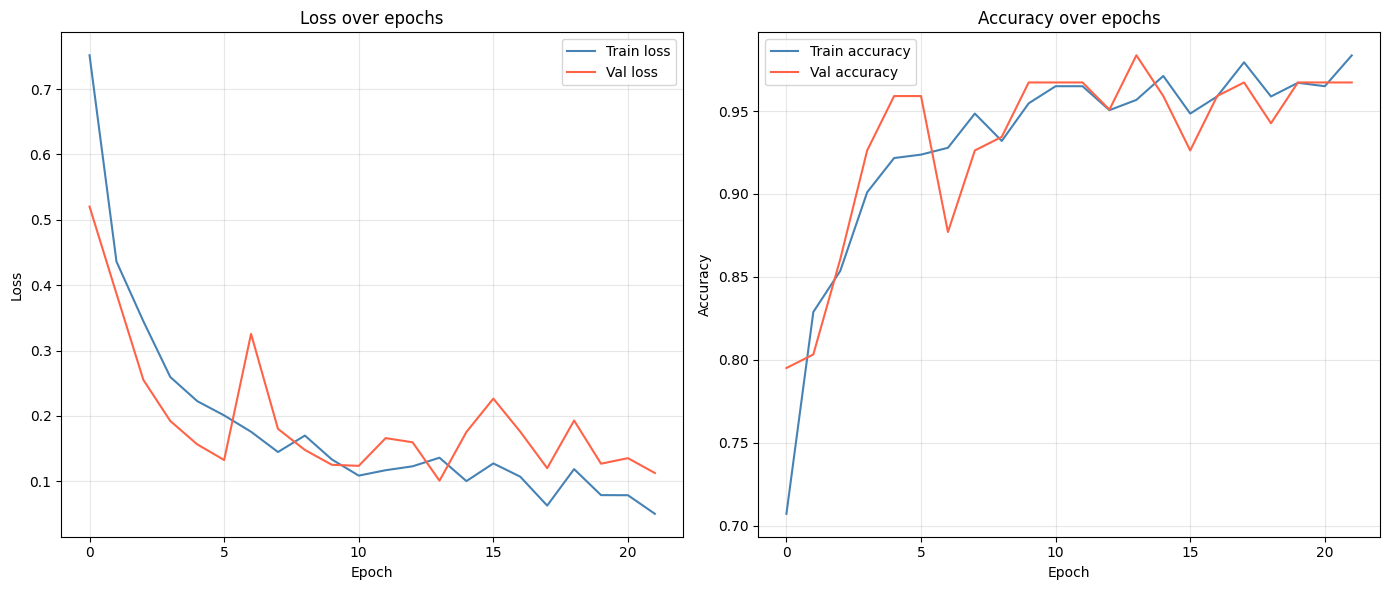

In [92]:

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(history.history['loss'], label='Train loss', color='steelblue')
ax1.plot(history.history['val_loss'], label='Val loss', color='tomato')
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['accuracy'], label='Train accuracy', color='steelblue')
ax2.plot(history.history['val_accuracy'], label='Val accuracy', color='tomato')
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

### Evaluate with confusion matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
              precision    recall  f1-score   support

    Balanced       0.98      1.00      0.99        40
     Slumped       1.00      0.95      0.98        42
    Restless       0.98      1.00      0.99        40

    accuracy                           0.98       122
   macro avg       0.98      0.98      0.98       122
weighted avg       0.98      0.98      0.98       122



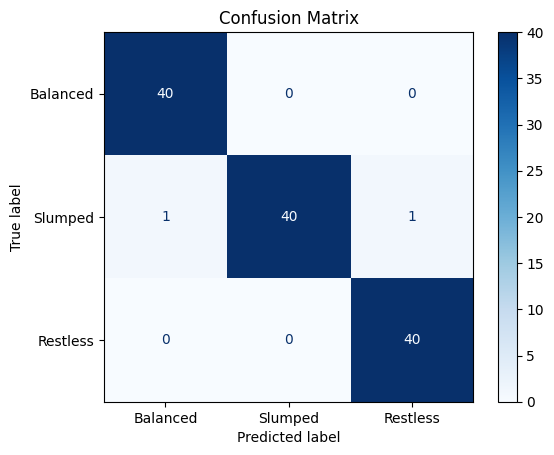

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

model.load_weights('soulsync_model.h5')

y_pred = np.argmax(model.predict(x_val), axis=1)

print(classification_report(y_val, y_pred, target_names = ['Balanced', 'Slumped', 'Restless']))

cm = confusion_matrix(y_val, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix = cm,
                          display_labels=['Balanced', 'Slumped', 'Restless'])

display.plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

In [101]:
import numpy as np

weights = model.get_weights()

# Save each weight array separately with its index
for i, w in enumerate(weights):
    np.save(f'weight_{i}.npy', w)
    files.download(f'weight_{i}.npy')

print(f'Saved {len(weights)} weight files.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved 7 weight files.


In [ ]:
from google.colab import files

for fname in ['scaler_mean.npy',
              'scaler_scale.npy',
              'training_curves.png',
              'confusion_matrix.png']:
    files.download(fname)
    print(f'Downloaded: {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: soulsync_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: confusion_matrix.png
